# Chapter 2 — End-to-End Machine Learning Project

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [30]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn import set_config
from sklearn.model_selection import (train_test_split, StratifiedShuffleSplit,
                                      cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, StandardScaler,
                                    MinMaxScaler, FunctionTransformer)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import (ColumnTransformer, TransformedTargetRegressor,
                              make_column_selector, make_column_transformer)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

## RMSE

$$
\mathrm{RMSE}(X, y, h) = \sqrt{\frac{1}{m} \sum_{i=1}^{m} \left( h(\mathbf{x}^{(i)}) - y^{(i)} \right)^2}
$$
La RMSE mide el promedio de los errores al cuadrado entre las predicciones y los valores reales. Penaliza más los errores grandes y es útil para evaluar modelos de regresión. Sus componentes son: $h(\mathbf{x}^{(i)})$ (predicción del modelo), $y^{(i)}$ (valor real), $m$ (número de muestras).

## MSE

$$
\mathrm{MSE}(X, y, h) = \frac{1}{m} \sum_{i=1}^{m} \left( h(\mathbf{x}^{(i)}) - y^{(i)} \right)
$$
La MSE (Error Cuadrático Medio) calcula el promedio de los errores al cuadrado entre las predicciones y los valores reales. Al igual que la RMSE, penaliza más los errores grandes, pero no toma la raíz cuadrada final. Sus componentes son: $h(\mathbf{x}^{(i)})$ (predicción del modelo), $y^{(i)}$ (valor real), $m$ (número de muestras).

In [31]:
def load_housing_data():
    csv_path = DATA_PATH / "housing/housing.csv"
    if not csv_path.exists():
        DATA_PATH.mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        import urllib.request, tarfile
        tarball_path = DATA_PATH / "housing.tgz"
        print("Downloading housing.tgz...")
        urllib.request.urlretrieve(url, tarball_path)
        print("Download complete.")
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path=DATA_PATH)
        print("Extraction complete.")
    return pl.read_csv(csv_path)

housing_full = load_housing_data()


In [32]:
housing_full.head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,f64,f64,str
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,"""NEAR BAY"""
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,"""NEAR BAY"""
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,"""NEAR BAY"""
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,"""NEAR BAY"""
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,"""NEAR BAY"""


In [33]:
housing_full.to_pandas().info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [34]:
housing_full.group_by("ocean_proximity").agg(pl.len())

ocean_proximity,len
str,u32
"""<1H OCEAN""",9136
"""ISLAND""",5
"""INLAND""",6551
"""NEAR BAY""",2290
"""NEAR OCEAN""",2658


In [35]:
housing_full.describe()

statistic,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",20640.0,20640.0,20640.0,20640.0,20433.0,20640.0,20640.0,20640.0,20640.0,"""20640"""
"""null_count""",0.0,0.0,0.0,0.0,207.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.53968,3.870671,206855.816909,null
"""std""",2.003532,2.135952,12.585558,2181.615252,421.38507,1132.462122,382.329753,1.899822,115395.615874,null
"""min""",-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0,"""<1H OCEAN"""
"""25%""",-121.8,33.93,18.0,1448.0,296.0,787.0,280.0,2.5637,119600.0,null
"""50%""",-118.49,34.26,29.0,2127.0,435.0,1166.0,409.0,3.5349,179700.0,null
"""75%""",-118.01,37.71,37.0,3148.0,647.0,1725.0,605.0,4.7431,264700.0,null
"""max""",-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,500001.0,"""NEAR OCEAN"""


In [36]:
from plotnine import *

C:\Users\evolu\AppData\Local\Temp\ipykernel_18024\1824360455.py:4: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
c:\Users\evolu\Desktop\Master\Ml_Torch_Sklrn\.conda\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_bin : Removed 207 rows containing non-finite values.


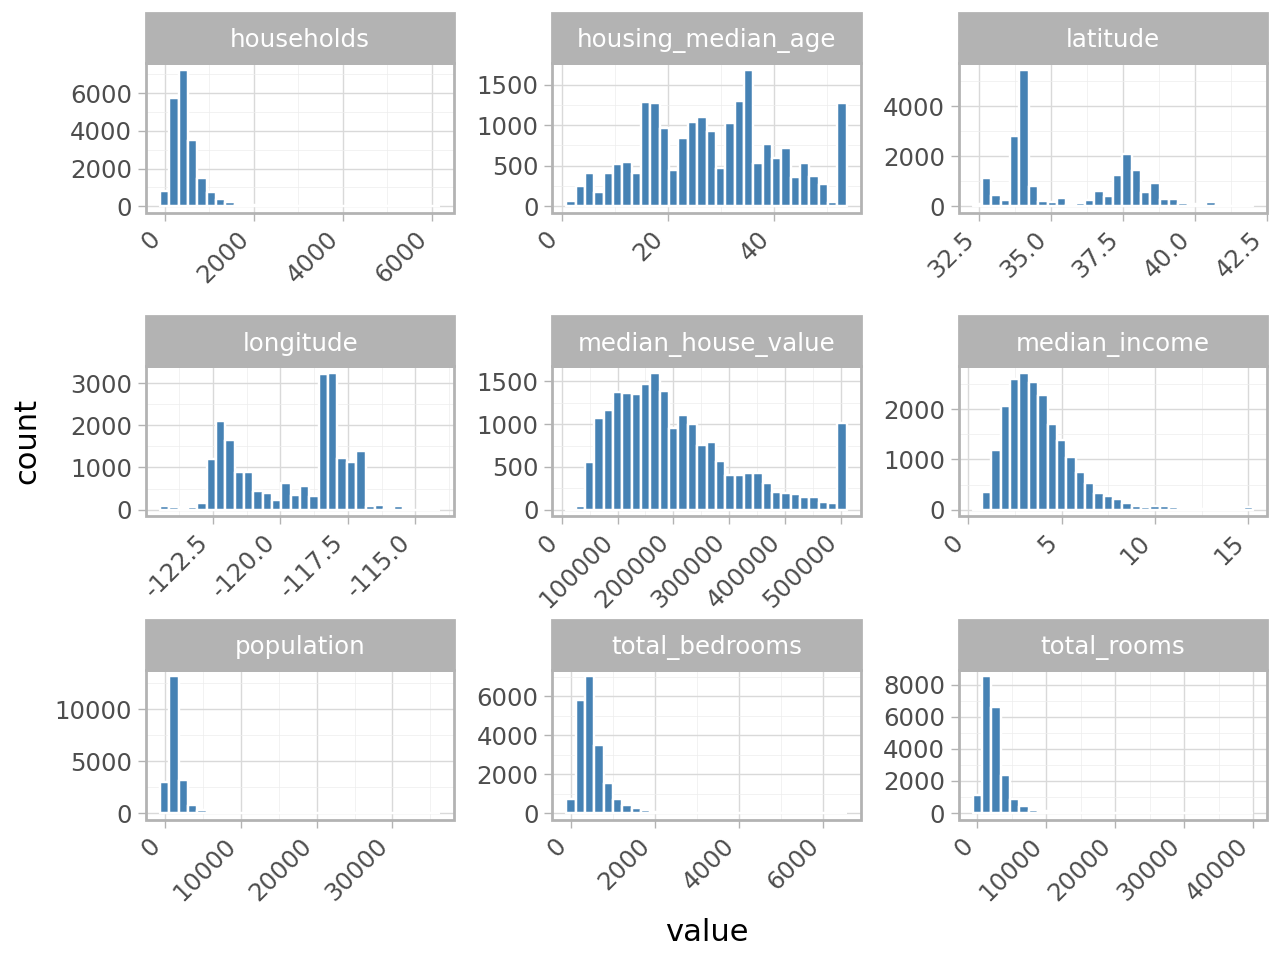

In [37]:
# Seleccionamos columnas numéricas en Polars
housing_melted = (
    housing_full
    .select(pl.col(pl.NUMERIC_DTYPES))
    .to_pandas()
    .melt()
)
(
    ggplot(housing_melted, aes(x='value'))
    + geom_histogram(bins=30, fill="steelblue", color="white")
    + facet_wrap('~variable', scales='free')
    + theme_light()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)